# Titanic Exploratory Data Analysis

## Project Overview

This is my fourth Python data science project.

In this project, I use a real Kaggle dataset: Titanic - Machine Learning from Disaster.

The goal is to practice exploratory data analysis before building a machine learning model.

Main tasks:

- Load a real CSV dataset
- Explore dataset structure
- Analyze missing values
- Clean data
- Create new features
- Visualize survival patterns
- Write key findings from data

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid")

In [9]:
for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [16]:
train = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")
test = pd.read_csv("/kaggle/input/competitions/titanic/test.csv")

train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Dataset Description

The Titanic dataset contains passenger information from the Titanic disaster.

The main target column is:

- Survived: whether the passenger survived or not

Column meaning:

- PassengerId: passenger ID
- Survived: survival status, 0 = did not survive, 1 = survived
- Pclass: ticket class
- Name: passenger name
- Sex: gender
- Age: passenger age
- SibSp: number of siblings/spouses aboard
- Parch: number of parents/children aboard
- Ticket: ticket number
- Fare: passenger fare
- Cabin: cabin number
- Embarked: port of embarkation

In [17]:
train.shape

train.info()

train.describe()

train.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [19]:
missing_values = train.isnull().sum().sort_values(ascending=False)

missing_values

missing_percent = (train.isnull().sum() / len(train) * 100). round(2)

missing_summary = pd.DataFrame({
    "Missing Values": train.isnull().sum(),
    "Missing Percentage": missing_percent
}).sort_values("Missing Values", ascending=False)

missing_summary

,Missing Values,Missing Percentage
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22
PassengerId,0,0.00
Name,0,0.00
Pclass,0,0.00
Survived,0,0.00
Sex,0,0.00
Parch,0,0.00
SibSp,0,0.00


## Missing Value Insight

The dataset contains missing values in some columns, especially Cabin and Age.

Before building a machine learning model, missing values need to be handled carefully.

In [21]:
survival_rate = train["Survived"].mean() * 100
print(f"Overall Survival Rate: {survival_rate:.2f}%")

Overall Survival Rate: 38.38%


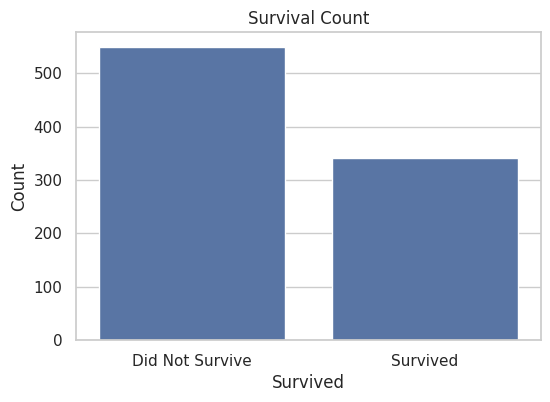

In [23]:
plt.figure(figsize=(6, 4))

sns.countplot(data=train, x="Survived")

plt.title("Survival Count")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.xticks([0, 1], ["Did Not Survive", "Survived"])
plt.show()

## Insight

The number of passengers who did not survive is higher than the number of passengers who survived.

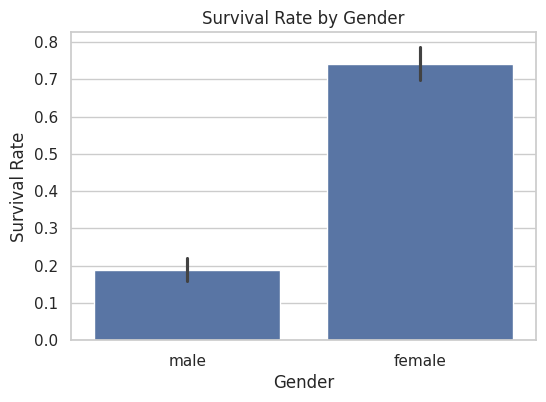

In [24]:
gender_survival = train.groupby("Sex")["Survived"].mean().sort_values(ascending=False)

gender_survival

plt.figure(figsize=(6, 4))

sns.barplot(data=train, x="Sex", y="Survived")

plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")
plt.show()

## Insight

Female passengers had a much higher survival rate than male passengers.

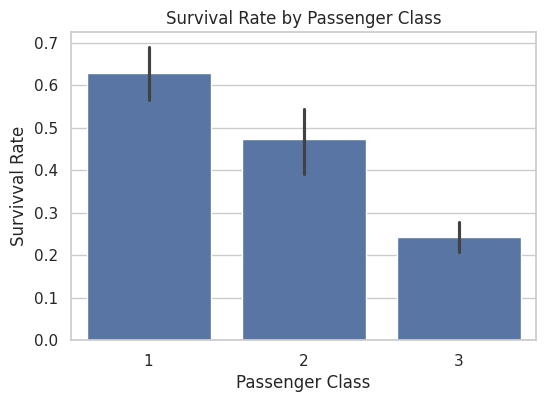

In [25]:
class_survival = train.groupby("Pclass")["Survived"].mean().sort_values(ascending=False)

class_survival

plt.figure(figsize=(6, 4))

sns.barplot(data=train, x="Pclass", y="Survived")

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survivval Rate")
plt.show()

## Insight

Passengers in higher classes had better survival rates.

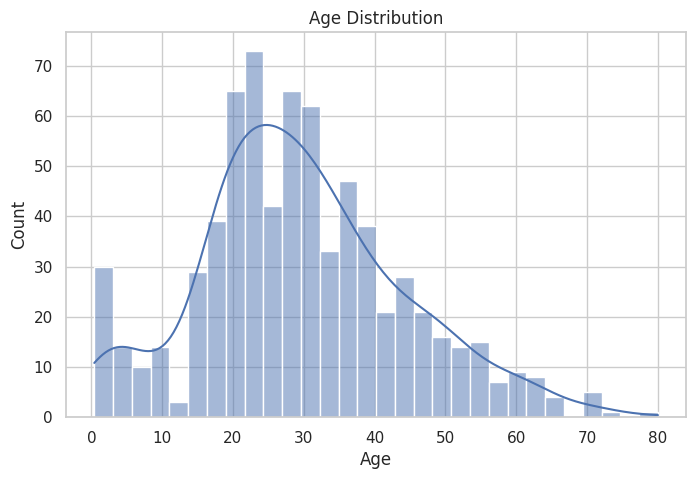

In [26]:
plt.figure(figsize=(8, 5))

sns.histplot(data=train, x="Age", bins=30, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

## Insight

The dataset includes passengers from different age groups. Some age values are missing and need to be handled before modeling.

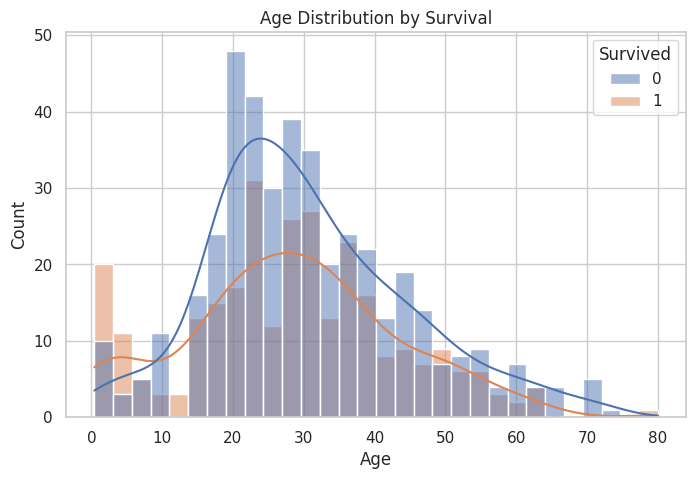

In [28]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=train,
    x="Age",
    hue="Survived",
    bins=30,
    kde=True
)

plt.title("Age Distribution by Survival")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

## Insight

Age may contain useful survival patterns, especially when comparing children, adults, and older passengers.

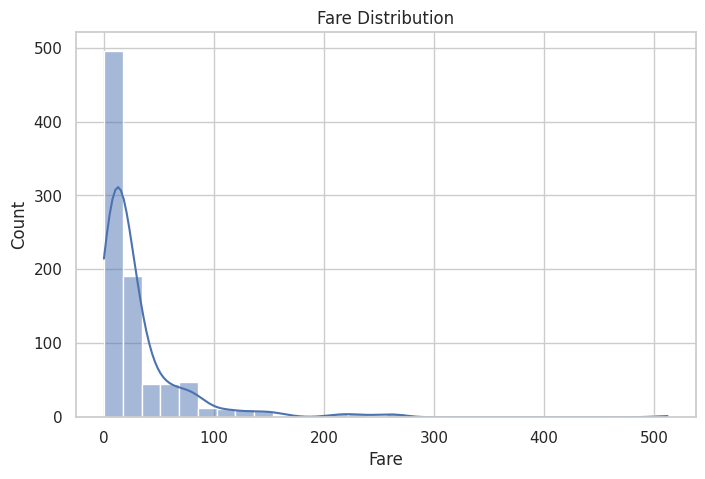

In [29]:
plt.figure(figsize=(8, 5))

sns.histplot(data=train, x="Fare", bins=30, kde=True)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Count")
plt.show()

## Insight

Fare is highly skewed. Most passengers paid lower fares, while a few passengers paid very high fares.

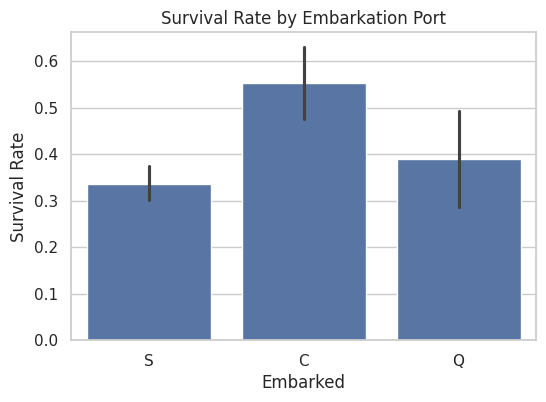

In [30]:
embarked_survival = train.groupby("Embarked")["Survived"].mean().sort_values(ascending=False)

embarked_survival

plt.figure(figsize=(6, 4))

sns.barplot(data=train, x="Embarked", y="Survived")

plt.title("Survival Rate by Embarkation Port")
plt.xlabel("Embarked")
plt.ylabel("Survival Rate")
plt.show()

## Insight

Survival rate differs by embarkation port, but this may also be related to passenger class and fare.

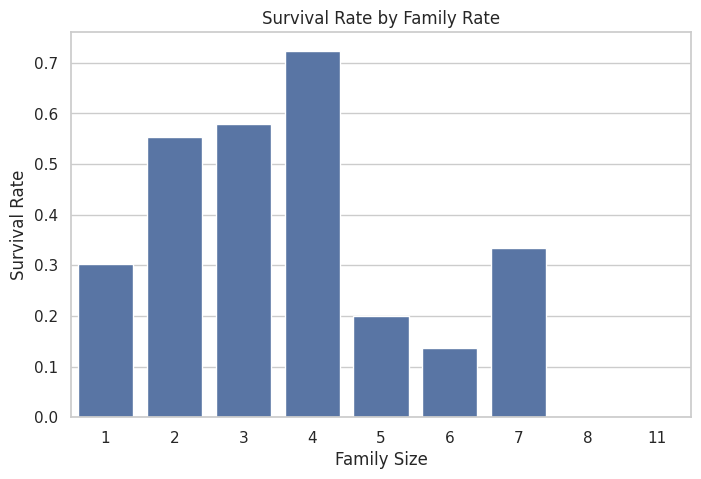

In [32]:
train["FamilySize"] = train["SibSp"] + train["Parch"] + 1
train[["SibSp", "Parch", "FamilySize"]].head()

family_survival = train.groupby("FamilySize")["Survived"].mean()
family_survival

plt.figure(figsize=(8, 5))

sns.barplot(x=family_survival.index, y=family_survival.values)

plt.title("Survival Rate by Family Rate")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate")
plt.show()

## Insight

Family size may be useful for machine learning because survival rate changes depending on whether passengers traveled alone or with family.

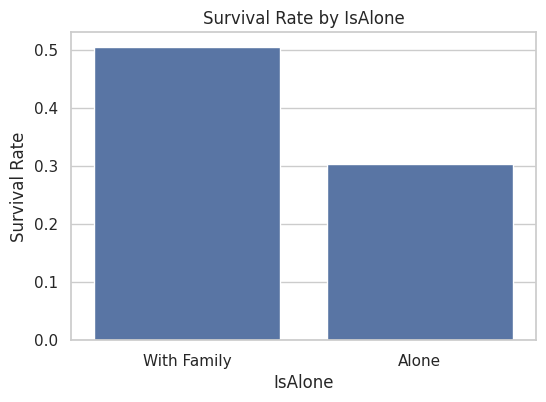

In [34]:
train["IsAlone"] = train["FamilySize"].apply(lambda x: 1 if x == 1 else 0)
train[["FamilySize", "IsAlone"]].head()

alone_survival = train.groupby("IsAlone")["Survived"].mean()
alone_survival

plt.figure(figsize=(6, 4))

sns.barplot(x=alone_survival.index, y=alone_survival.values)

plt.title("Survival Rate by IsAlone")
plt.xlabel("IsAlone")
plt.ylabel("Survival Rate")
plt.xticks([0, 1], ["With Family", "Alone"])
plt.show()

/tmp/ipykernel_58/4115668500.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agegroup_survival = train.groupby("AgeGroup")["Survived"].mean()


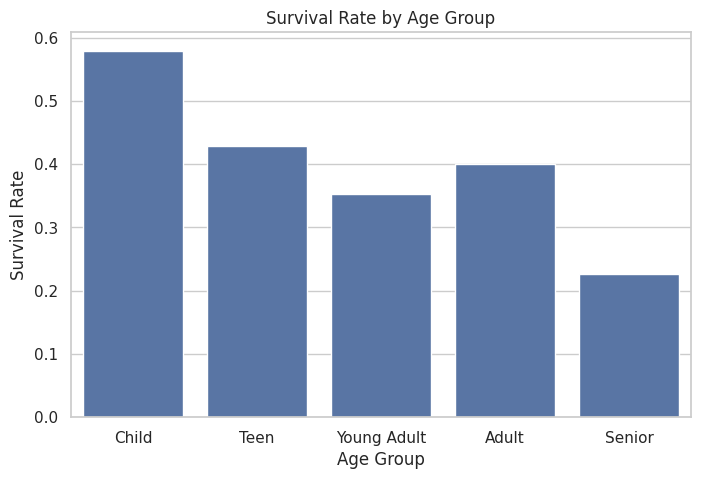

In [37]:
train["Age_Filled"] = train["Age"].fillna(train["Age"].median())

train["AgeGroup"] = pd.cut(
    train["Age_Filled"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["Child", "Teen", "Young Adult", "Adult", "Senior"]
)
train[["Age", "Age_Filled", "AgeGroup"]].head()

agegroup_survival = train.groupby("AgeGroup")["Survived"].mean()
agegroup_survival

plt.figure(figsize=(8, 5))

sns.barplot(x=agegroup_survival.index, y=agegroup_survival.values)

plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate")
plt.show()

## Insight

Age groups can help reveal survival patterns more clearly than raw age values.

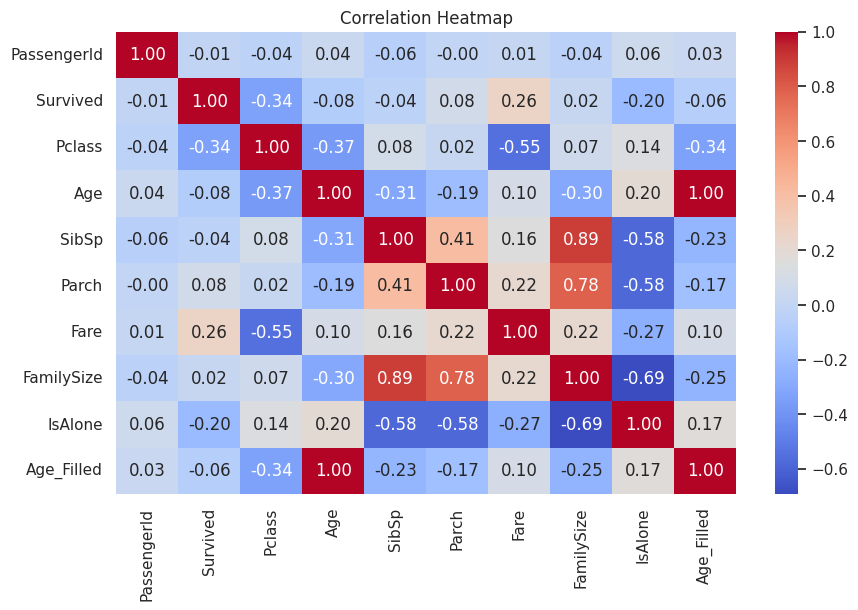

In [41]:
numeric_cols = train.select_dtypes(include=["int64", "float64"])

corr = numeric_cols.corr()

plt.figure(figsize=(10, 6))

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

## Insight

The correlation heatmap helps identify numeric features that may be useful for machine learning.

In [43]:
cleaned_train = train.copy()

cleaned_train["Age"] = cleaned_train["Age"].fillna(cleaned_train["Age"].median())
cleaned_train["Embarked"] = cleaned_train["Embarked"].fillna(cleaned_train["Embarked"].mode()[0])
cleaned_train["Fare"] = cleaned_train["Fare"].fillna(cleaned_train["Fare"].median())

cleaned_train.isnull().sum().sort_values(ascending=False)

Cabin          687
PassengerId      0
Pclass           0
Survived         0
Sex              0
Age              0
SibSp            0
Name             0
Parch            0
Ticket           0
Fare             0
Embarked         0
FamilySize       0
IsAlone          0
Age_Filled       0
AgeGroup         0
dtype: int64

In [48]:
selected_columns = [
    "PassengerId",
    "Survived",
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "FamilySize",
    "IsAlone",
    "Fare",
    "Embarked",
    "AgeGroup"
]

cleaned_train = cleaned_train[selected_columns]

cleaned_train.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,FamilySize,IsAlone,Fare,Embarked,AgeGroup
0,1,0,3,male,22.0,1,0,2,0,7.2500,S,Young Adult
1,2,1,1,female,38.0,1,0,2,0,71.2833,C,Adult
2,3,1,3,female,26.0,0,0,1,1,7.9250,S,Young Adult
3,4,1,1,female,35.0,1,0,2,0,53.1000,S,Young Adult
4,5,0,3,male,35.0,0,0,1,1,8.0500,S,Young Adult


In [50]:
cleaned_train.to_csv("/kaggle/working/titanic_cleaned_train.csv", index=False)

print("Cleaned Titanic dataset exported successfully.")

os.listdir("/kaggle/working")

Cleaned Titanic dataset exported successfully.


['titanic_cleaned_train.csv', '.virtual_documents']

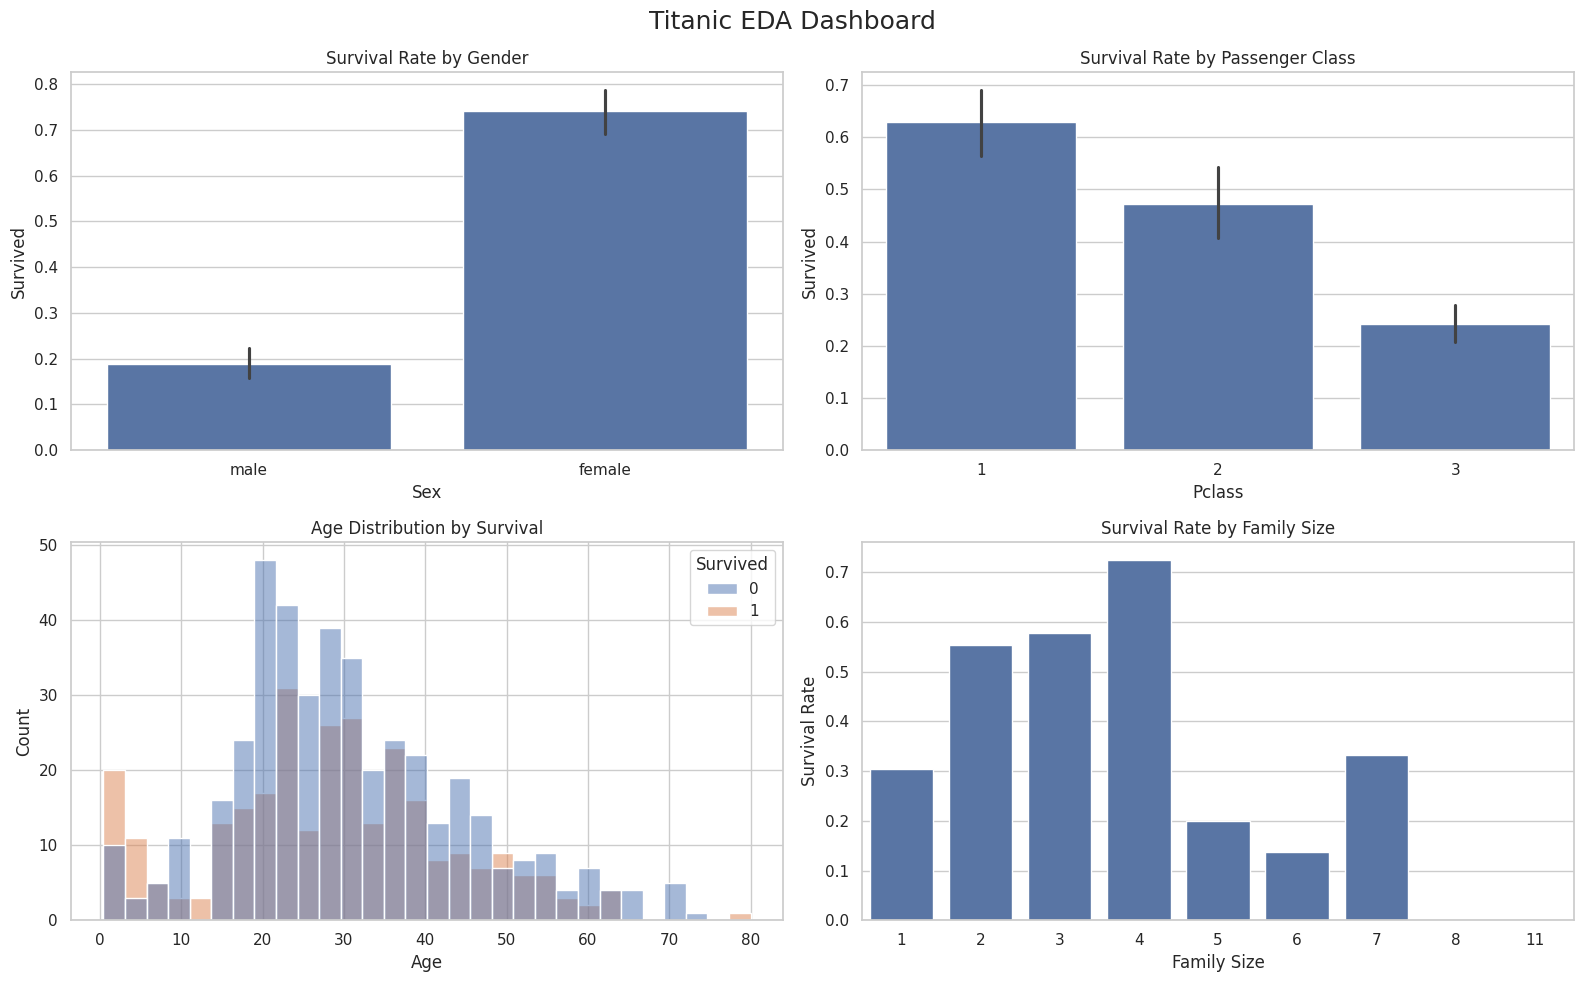

/kaggle/working/titanic_eda_dashboard.png

In [54]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.barplot(data=train, x="Sex", y="Survived", ax=axes[0, 0])
axes[0, 0].set_title("Survival Rate by Gender")

sns.barplot(data=train, x="Pclass", y="Survived", ax=axes[0, 1])
axes[0, 1].set_title("Survival Rate by Passenger Class")

sns.histplot(data=train, x="Age", hue="Survived", bins=30, ax=axes[1, 0])
axes[1, 0].set_title("Age Distribution by Survival")

sns.barplot(x=family_survival.index, y=family_survival.values, ax=axes[1, 1])
axes[1, 1].set_title("Survival Rate by Family Size")
axes[1, 1].set_xlabel("Family Size")
axes[1, 1].set_ylabel("Survival Rate")

plt.suptitle("Titanic EDA Dashboard", fontsize=18)
plt.tight_layout()

plt.savefig("/kaggle/working/titanic_eda_dashboard.png", dpi=300, bbox_inches="tight")
plt.show()

from IPython.display import FileLink

FileLink("/kaggle/working/titanic_eda_dashboard.png")

## Key Findings

From this Titanic exploratory data analysis project, I found that:

1. Female passengers had a much higher survival rate than male passengers.
2. Passengers in higher ticket classes had better survival rates.
3. Age contains missing values and needs to be cleaned before modeling.
4. Fare is highly skewed, with most passengers paying lower fares.
5. Family size appears to be related to survival.
6. Passengers traveling alone may have different survival patterns compared to passengers traveling with family.
7. New features such as FamilySize, IsAlone, and AgeGroup may be useful for machine learning.

## What I Learned

In this project, I practiced:

- Loading a real Kaggle dataset
- Exploring dataset structure
- Checking missing values
- Calculating survival rates
- Creating visualizations with Seaborn and Matplotlib
- Creating new features for analysis
- Saving cleaned data
- Writing insights from real data

## Next Step

The next step is to build a machine learning model to predict Titanic passenger survival.